# Gesture Recognition (TO BE RUN IN GOOGLE COLAB)

In this project, we are going to build a 3D Conv model that will be able to predict the 5 gestures correctly. Please import the following libraries to get started.

Problem Statement
Imagine we are working as a data scientist at a home electronics company which manufactures state of the art smart televisions. We want to develop a cool feature in the smart-TV that can recognise five different gestures performed by the user which will help users control the TV without using a remote.
The gestures are continuously monitored by the webcam mounted on the TV. Each gesture corresponds to a specific command:

- Thumbs up:  Increase the volume
- Thumbs down: Decrease the volume
- Left swipe: 'Jump' backwards 10 seconds
- Right swipe: 'Jump' forward 10 seconds  
- Stop: Pause the movie


Each video is a sequence of 30 frames (or images).



In [1]:
import kagglehub
gesture_recognition_path = kagglehub.dataset_download('imsparsh/gesture-recognition')

100%|██████████| 1.60G/1.60G [00:19<00:00, 87.3MB/s]

Extracting files...


In [2]:
print(gesture_recognition_path)

/root/.cache/kagglehub/datasets/imsparsh/gesture-recognition/versions/2


In [3]:
!ls /root/.cache/kagglehub/datasets/imsparsh/gesture-recognition/versions/2

LICENSE  README.md  train  train.csv  val  val.csv


In [4]:
import numpy as np
import os
import imageio
from skimage.transform import resize, rescale
import datetime
import os

import matplotlib.pyplot as plt

from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, GRU, LSTM, Flatten, TimeDistributed, Flatten, BatchNormalization, Activation
from keras.layers import Conv3D, MaxPooling3D, Conv2D, MaxPooling2D
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.regularizers import l2
from keras import optimizers

We set the random seed so that the results don't vary drastically.

In [5]:
import tensorflow as tf
print(tf.__version__)
np.random.seed(30)
import random as rn
rn.seed(30)
from keras import backend as K
tf.random.set_seed(30)

2.19.0


In this block, you read the folder names for training and validation. You also set the `batch_size` here. Note that you set the batch size in such a way that you are able to use the GPU in full capacity. You keep increasing the batch size until the machine throws an error.

In [6]:
train_doc = np.random.permutation(open('/root/.cache/kagglehub/datasets/imsparsh/gesture-recognition/versions/2/train.csv').readlines())
val_doc = np.random.permutation(open('/root/.cache/kagglehub/datasets/imsparsh/gesture-recognition/versions/2/val.csv').readlines())
num_classes = 5  #number of softmax classes

In [7]:
curr_dt_time = datetime.datetime.now()
train_path = '/root/.cache/kagglehub/datasets/imsparsh/gesture-recognition/versions/2/train'
val_path = '/root/.cache/kagglehub/datasets/imsparsh/gesture-recognition/versions/2/val'
num_train_sequences = len(train_doc)
print('# training sequences =', num_train_sequences)
num_val_sequences = len(val_doc)
print('# validation sequences =', num_val_sequences)

# training sequences = 663
# validation sequences = 100


## Common Utils

Common utility to plot loss and accuracy

In [8]:
def plot_loss_accuracy(history):
    # list all data in history
    print(history.history.keys())
    # summarize history for accuracy
    plt.plot(history.history['categorical_accuracy'])
    plt.plot(history.history['val_categorical_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()
    # summarize history for loss
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()

Common utility to calculate steps

In [9]:
def calculate_steps(num_train_sequences, num_val_sequences, batch_size):
    if (num_train_sequences%batch_size) == 0:
        steps_per_epoch = int(num_train_sequences/batch_size)
    else:
        steps_per_epoch = (num_train_sequences//batch_size) + 1

    if (num_val_sequences%batch_size) == 0:
        validation_steps = int(num_val_sequences/batch_size)
    else:
        validation_steps = (num_val_sequences//batch_size) + 1

    return steps_per_epoch,validation_steps

Common utility for callbacks

In [10]:
def model_callbacks(folder_name):
    model_name = str(folder_name) + '_' + str(curr_dt_time).replace(' ','').replace(':','_') + '/'

    if not os.path.exists(model_name):
        os.mkdir(model_name)

    filepath = model_name + 'model-{epoch:05d}-{loss:.5f}-{categorical_accuracy:.5f}-{val_loss:.5f}-{val_categorical_accuracy:.5f}.h5'

    checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1, save_best_only=True, save_weights_only=False, mode='auto', save_freq='epoch')

    LR = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, min_lr=0.0001, cooldown=1, verbose=1) # write the REducelronplateau code here

    return [checkpoint, LR]

## Generator
This is one of the most important part of the code. The overall structure of the generator has been given. In the generator, we are going to preprocess the images as you have images of 2 different dimensions as well as create a batch of video frames. we have to experiment with `img_idx`, `y`,`z` and normalization such that we get high accuracy.

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1047: UserWarning: This ImageDataGenerator specifies `zca_whitening`, which overrides setting of `featurewise_center`.
  warnings.warn(
/tmp/ipython-input-1064/3642445817.py:12: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image1 = imageio.imread("/root/.cache/kagglehub/datasets/imsparsh/gesture-recognition/versions/2/train/WIN_20180907_15_35_09_Pro_Right Swipe_new/WIN_20180907_15_35_09_Pro_00012.png")
/tmp/ipython-input-1064/3642445817.py:14: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image2 = imagei

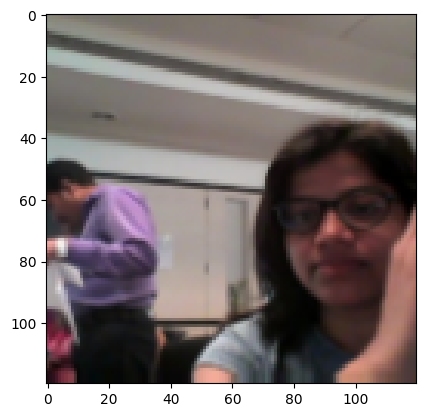

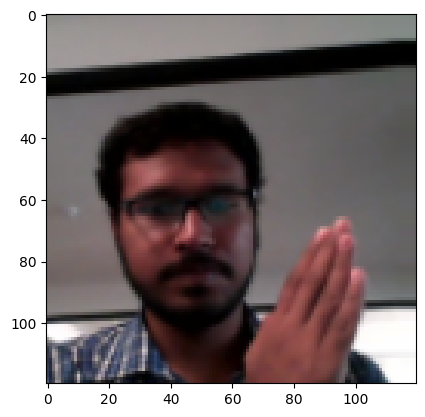

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#from keras.preprocessing.image import smart_resize

datagen = ImageDataGenerator(
    zoom_range=0.1,
    zca_whitening=True,
    width_shift_range=0.1,
    height_shift_range=0.1)

## Test code start
#360 by 360
image1 = imageio.imread("/root/.cache/kagglehub/datasets/imsparsh/gesture-recognition/versions/2/train/WIN_20180907_15_35_09_Pro_Right Swipe_new/WIN_20180907_15_35_09_Pro_00012.png")
#160 by 120
image2 = imageio.imread("/root/.cache/kagglehub/datasets/imsparsh/gesture-recognition/versions/2/val/WIN_20180907_15_30_06_Pro_Right Swipe_new/WIN_20180907_15_30_06_Pro_00015.png")
#crop the images and resize them. Note that the images are of 2 different shape
#and the conv3D will throw error if the inputs in a batch have different shapes
#print(image1.shape, image2.shape)
image1 = resize(image1, (120, 120), anti_aliasing=True)
image1 = datagen.random_transform(image1)
plt.imshow(image1)
plt.show()
image2 = resize(image2, (120, 120), anti_aliasing=True)
image2 = datagen.random_transform(image2)
plt.imshow(image2)
plt.show()
## Test code end

def generate(source_path, folder_list, batch_size, num_images=20, height=120, width=120, augment=False):
    #print( 'Source path = ', source_path, '; batch size =', batch_size)
    total_frames = 30

    while True:
        t = np.random.permutation(folder_list)
        num_batches = len(t)//batch_size # calculate the number of batches
        #img_idx = sorted(rn.sample(range(0, total_frames), num_images)) #create a list of image numbers you want to use for a particular video
        img_idx = np.round(np.linspace(0,total_frames-1,num_images)).astype(int) #create a list of image numbers you want to use for a particular video

        for batch in range(num_batches): # we iterate over the number of batches
            batch_data   = np.zeros((batch_size, num_images, height, width, 3)) # 3 is the number of channels RGB
            batch_labels = np.zeros((batch_size, 5)) # batch_labels is the one hot representation of the output

            for folder in range(batch_size): # iterate over the batch_size
                imgs = os.listdir(source_path+'/'+ t[folder + (batch*batch_size)].split(';')[0]) # read all the images in the folder
                for idx,item in enumerate(img_idx): #  Iterate over the frames/images of a folder to read them in
                    image = imageio.imread(source_path+'/'+ t[folder + (batch*batch_size)].strip().split(';')[0]+'/'+imgs[item]).astype(np.float32)

                    #crop the images and resize them. Note that the images are of 2 different shape
                    #and the conv3D will throw error if the inputs in a batch have different shapes
                    h, w, c = image.shape
                    image = resize(image, (height, width), anti_aliasing=True)

                    # Randomly transform few images of few folders; note that folders are randomly shuffled in each epoch too
                    if augment:
                        if np.random.randn() > 0:
                            image = datagen.random_transform(image)

                    batch_data[folder,idx,:,:,0] = (image[...,0])/255 #normalise and feed in the image
                    batch_data[folder,idx,:,:,1] = (image[...,1])/255 #normalise and feed in the image
                    batch_data[folder,idx,:,:,2] = (image[...,2])/255 #normalise and feed in the image

                batch_labels[folder, int(t[folder + (batch*batch_size)].strip().split(';')[2])] = 1

            yield batch_data, batch_labels #you yield the batch_data and the batch_labels, remember what does yield do

        # write the code for the remaining data points which are left after full batches
        if (len(t)%batch_size):
            remaining_batch_size = len(t)%batch_size
            batch_data   = np.zeros((remaining_batch_size, num_images, height, width,3)) # 3 is the number of channels RGB
            batch_labels = np.zeros((remaining_batch_size,5)) # batch_labels is the one hot representation of the output

            for folder in range(remaining_batch_size): # iterate over the batch_size
                imgs = os.listdir(source_path+'/'+ t[folder + (num_batches*batch_size)].split(';')[0]) # read all the images in the folder
                for idx,item in enumerate(img_idx): #  Iterate iver the frames/images of a folder to read them in
                    image = imageio.imread(source_path+'/'+ t[folder + (num_batches*batch_size)].strip().split(';')[0]+'/'+imgs[item]).astype(np.float32)

                    #crop the images and resize them. Note that the images are of 2 different shape
                    #and the conv3D will throw error if the inputs in a batch have different shapes
                    h, w, c = image.shape
                    image = resize(image, (height, width), anti_aliasing=True)

                    # Randomly transform few images of few folders; note that folders are randomly shuffled in each epoch too
                    if augment:
                        if np.random.randn() > 0:
                            image = datagen.random_transform(image)

                    batch_data[folder,idx,:,:,0] = (image[...,0])/255 #normalise and feed in the image
                    batch_data[folder,idx,:,:,1] = (image[...,1])/255 #normalise and feed in the image
                    batch_data[folder,idx,:,:,2] = (image[...,2])/255 #normalise and feed in the image

                batch_labels[folder, int(t[folder + (num_batches*batch_size)].strip().split(';')[2])] = 1

            yield batch_data, batch_labels #you yield the batch_data and the batch_labels, remember what does yield do


Note here that a video is represented above in the generator as (number of images, height, width, number of channels). Take this into consideration while creating the model architecture.

## Model
Here we make the model using different functionalities that Keras provides. We will use `Conv3D` and `MaxPooling3D` and not `Conv2D` and `Maxpooling2D` for a 3D convolution model. We would want to use `TimeDistributed` while building a Conv2D + RNN model. Also remember that the last layer is the softmax. We will Design the network in such a way that the model is able to give good accuracy on the least number of parameters so that it can fit in the memory of the webcam.

In [12]:
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, GRU, LSTM, Flatten, TimeDistributed, Flatten, BatchNormalization, Activation
from keras.layers import Conv3D, MaxPooling3D, Conv2D, MaxPooling2D
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.regularizers import l2
from keras import optimizers

### Conv3d Models

In [13]:
# Common utility to create conv 3D models
def conv3D(conv_filters=(16, 32, 64, 128), dense_nodes=(256,128), dropout=0.25, num_images=20, height=120, width=120):

    model = Sequential()

    model.add(Conv3D(conv_filters[0], (3, 3, 3), padding='same', input_shape=(num_images, height, width, 3)))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling3D(pool_size=(2, 2, 2)))

    model.add(Conv3D(conv_filters[1], (3, 3, 3), padding='same'))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling3D(pool_size=(2, 2, 2)))

    model.add(Conv3D(conv_filters[2], (3, 3, 3), padding='same'))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling3D(pool_size=(2, 2, 2)))

    model.add(Conv3D(conv_filters[3], (3, 3, 3), padding='same'))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling3D(pool_size=(2, 2, 2)))

    model.add(Flatten())
    model.add(Dense(dense_nodes[0]))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))

    model.add(Dense(dense_nodes[1]))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))

    model.add(Dense(num_classes))
    model.add(Activation('softmax'))

    opt = tf.keras.optimizers.Adam() #write your optimizer
    model.compile(opt, loss='categorical_crossentropy', metrics=['categorical_accuracy'])

    return model

### TRANSFER LEARNING - MobileNet Conv2d + GRU

In [14]:
from keras.applications import mobilenet

def mobilenet_RNN(fine_tune=False, gru=False, lstm_gru_cells=128, dense_nodes=128, dropout=0.25, num_images=20, height=120, width=120):

    mobilenet_transfer = mobilenet.MobileNet(weights='imagenet', include_top=False)
    print("Number of layers in the pretrained mobilenet model: ", len(mobilenet_transfer.layers))

    if (fine_tune):
        # Fine-tune from this layer onwards
        fine_tune_at = 50
        # Freeze all the layers before the `fine_tune_at` layer
        for layer in mobilenet_transfer.layers[:fine_tune_at]:
            layer.trainable = False

    model = Sequential()
    model.add(TimeDistributed(mobilenet_transfer,input_shape=(num_images, height, width, 3)))
    model.add(TimeDistributed(BatchNormalization()))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    model.add(TimeDistributed(Flatten()))
    if (gru):
        model.add(GRU(lstm_gru_cells))
    else:
        model.add(LSTM(lstm_gru_cells))
    model.add(Dropout(dropout))
    model.add(Dense(dense_nodes, activation='relu'))
    model.add(Dropout(dropout))
    model.add(Dense(num_classes, activation='softmax'))

    opt = tf.keras.optimizers.Adam() #write your optimizer
    model.compile(opt, loss='categorical_crossentropy', metrics=['categorical_accuracy'])
    return model

#### Model 9: Mobilenet (re train all weights) + GRU (128 cells) + 128 dense nodes + Random data transformations on training data set

In [15]:
num_epochs = 15 # choose the number of epochs
print ('# epochs =', num_epochs)
batch_size = 10  #experiment with the batch size
print ('# batch size =', batch_size)
num_frames = 30
print ('# num frames per video =', num_frames)
height = 120
width = 120

model = mobilenet_RNN(gru=True, num_images=num_frames)
print(model.summary())

# epochs = 15
# batch size = 10
# num frames per video = 30


/tmp/ipython-input-1064/4203285966.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_transfer = mobilenet.MobileNet(weights='imagenet', include_top=False)


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of layers in the pretrained mobilenet model:  86


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 30, 3, 3, 1024) │     3,228,864 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 30, 3, 3, 1024) │         4,096 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 30, 1, 1, 1024) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 30, 1024)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │       443,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,693,253 (14.09 MB)

 Trainable params: 3,669,317 (14.00 MB)

 Non-trainable params: 23,936 (93.50 KB)

None


In [16]:
callbacks_list = model_callbacks("model_retrain_mobilenet_gru")

steps_per_epoch, validation_steps = calculate_steps(num_train_sequences, num_val_sequences, batch_size)

train_generator = generate(train_path, train_doc, batch_size, augment=True, num_images=num_frames)

val_generator   = generate(val_path, val_doc, batch_size, num_images=num_frames)

In [17]:
history = model.fit(train_generator, steps_per_epoch=steps_per_epoch, epochs=num_epochs, verbose=1,
                              callbacks=callbacks_list, validation_data=val_generator,
                              validation_steps=validation_steps, class_weight=None, initial_epoch=0)

/tmp/ipython-input-1064/3642445817.py:45: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(source_path+'/'+ t[folder + (batch*batch_size)].strip().split(';')[0]+'/'+imgs[item]).astype(np.float32)


Epoch 1/15
65/67 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - categorical_accuracy: 0.3687 - loss: 1.5440

/tmp/ipython-input-1064/3642445817.py:74: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(source_path+'/'+ t[folder + (num_batches*batch_size)].strip().split(';')[0]+'/'+imgs[item]).astype(np.float32)


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - categorical_accuracy: 0.3717 - loss: 1.5361
Epoch 1: val_loss improved from inf to 0.73609, saving model to model_retrain_mobilenet_gru_2026-03-0114_16_53.021072/model-00001-1.28129-0.46908-0.73609-0.70000.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 451s 4s/step - categorical_accuracy: 0.3731 - loss: 1.5324 - val_categorical_accuracy: 0.7000 - val_loss: 0.7361 - learning_rate: 0.0010
Epoch 2/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - categorical_accuracy: 0.7276 - loss: 0.6452
Epoch 2: val_loss improved from 0.73609 to 0.46517, saving model to model_retrain_mobilenet_gru_2026-03-0114_16_53.021072/model-00002-0.60207-0.76320-0.46517-0.82000.h5


...

67/67 ━━━━━━━━━━━━━━━━━━━━ 235s 4s/step - categorical_accuracy: 0.9165 - loss: 0.2782 - val_categorical_accuracy: 0.9500 - val_loss: 0.1546 - learning_rate: 0.0010
Epoch 6/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - categorical_accuracy: 0.9412 - loss: 0.1750
Epoch 6: val_loss did not improve from 0.15456
67/67 ━━━━━━━━━━━━━━━━━━━━ 235s 4s/step - categorical_accuracy: 0.9413 - loss: 0.1750 - val_categorical_accuracy: 0.9200 - val_loss: 0.2280 - learning_rate: 0.0010
Epoch 7/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - categorical_accuracy: 0.8490 - loss: 0.5149
Epoch 7: val_loss did not improve from 0.15456
67/67 ━━━━━━━━━━━━━━━━━━━━ 235s 4s/step - categorical_accuracy: 0.8493 - loss: 0.5129 - val_categorical_accuracy: 0.8600 - val_loss: 0.2958 - learning_rate: 0.0010
Epoch 8/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - categorical_accuracy: 0.9432 - loss: 0.1573
Epoch 8: val_loss did not improve from 0.15456

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
67/6

67/67 ━━━━━━━━━━━━━━━━━━━━ 236s 4s/step - categorical_accuracy: 0.9845 - loss: 0.0614 - val_categorical_accuracy: 0.9400 - val_loss: 0.1335 - learning_rate: 1.0000e-04
Epoch 10/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - categorical_accuracy: 0.9808 - loss: 0.0540
Epoch 10: val_loss did not improve from 0.13349
67/67 ━━━━━━━━━━━━━━━━━━━━ 238s 4s/step - categorical_accuracy: 0.9807 - loss: 0.0542 - val_categorical_accuracy: 0.9500 - val_loss: 0.1440 - learning_rate: 1.0000e-04
Epoch 11/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - categorical_accuracy: 0.9838 - loss: 0.0510
Epoch 11: val_loss improved from 0.13349 to 0.08692, saving model to model_retrain_mobilenet_gru_2026-03-0114_16_53.021072/model-00011-0.05003-0.98039-0.08692-0.96000.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 246s 4s/step - categorical_accuracy: 0.9837 - loss: 0.0510 - val_categorical_accuracy: 0.9600 - val_loss: 0.0869 - learning_rate: 1.0000e-04
Epoch 12/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - categorical_accuracy: 0.9774 - loss: 0.0810
Epoch 12: val_loss improved from 0.08692 to 0.06639, saving model to model_retrain_mobilenet_gru_2026-03-0114_16_53.021072/model-00012-0.05463-0.98341-0.06639-0.97000.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 319s 5s/step - categorical_accuracy: 0.9775 - loss: 0.0806 - val_categorical_accuracy: 0.9700 - val_loss: 0.0664 - learning_rate: 1.0000e-04
Epoch 13/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - categorical_accuracy: 0.9930 - loss: 0.0331
Epoch 13: val_loss did not improve from 0.06639
67/67 ━━━━━━━━━━━━━━━━━━━━ 256s 4s/step - categorical_accuracy: 0.9930 - loss: 0.0332 - val_categorical_accuracy: 0.9400 - val_loss: 0.2151 - learning_rate: 1.0000e-04
Epoch 14/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - categorical_accuracy: 1.0000 - loss: 0.0130
Epoch 14: val_loss improved from 0.06639 to 0.03136, saving model to model_retrain_mobilenet_gru_2026-03-0114_16_53.021072/model-00014-0.01718-1.00000-0.03136-0.99000.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 260s 4s/step - categorical_accuracy: 1.0000 - loss: 0.0131 - val_categorical_accuracy: 0.9900 - val_loss: 0.0314 - learning_rate: 1.0000e-04
Epoch 15/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - categorical_accuracy: 0.9872 - loss: 0.0271
Epoch 15: val_loss did not improve from 0.03136
67/67 ━━━━━━━━━━━━━━━━━━━━ 252s 4s/step - categorical_accuracy: 0.9872 - loss: 0.0272 - val_categorical_accuracy: 0.9800 - val_loss: 0.0867 - learning_rate: 1.0000e-04


dict_keys(['categorical_accuracy', 'loss', 'val_categorical_accuracy', 'val_loss', 'learning_rate'])


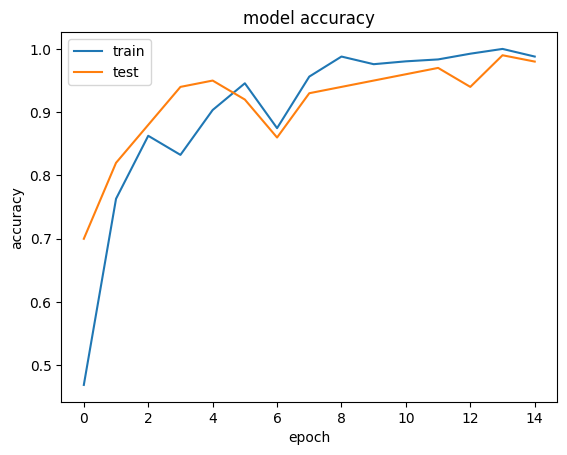

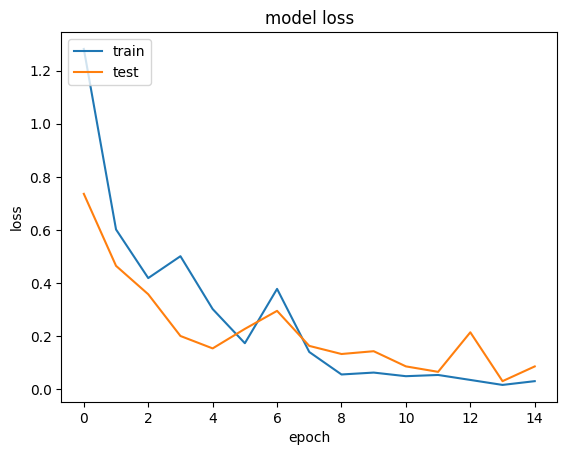

In [18]:
plot_loss_accuracy(history)

#### Model 10: Mobilenet (re train all wieghts) + LSTM (128 cells) + 128 dense nodes




In [19]:
num_epochs = 15 # choose the number of epochs
print ('# epochs =', num_epochs)
batch_size = 10  #experiment with the batch size
print ('# batch size =', batch_size)
num_frames = 20
print ('# num frames per video =', num_frames)
height = 120
width = 120

model = mobilenet_RNN(fine_tune=False, gru=False, num_images=num_frames)
print(model.summary())

# epochs = 15
# batch size = 10
# num frames per video = 20


/tmp/ipython-input-1064/4203285966.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_transfer = mobilenet.MobileNet(weights='imagenet', include_top=False)


Number of layers in the pretrained mobilenet model:  86


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_4              │ (None, 20, 3, 3, 1024) │     3,228,864 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 20, 3, 3, 1024) │         4,096 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 20, 1, 1, 1024) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 20, 1024)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,840,453 (14.65 MB)

 Trainable params: 3,816,517 (14.56 MB)

 Non-trainable params: 23,936 (93.50 KB)

None


In [20]:
callbacks_list = model_callbacks("model_retrain_mobilenet_lstm")

steps_per_epoch, validation_steps = calculate_steps(num_train_sequences, num_val_sequences, batch_size)

train_generator = generate(train_path, train_doc, batch_size, num_images=num_frames)

val_generator   = generate(val_path, val_doc, batch_size, num_images=num_frames)

In [21]:
history = model.fit(train_generator, steps_per_epoch=steps_per_epoch, epochs=num_epochs, verbose=1,
                              callbacks=callbacks_list, validation_data=val_generator,
                              validation_steps=validation_steps, class_weight=None, initial_epoch=0)

/tmp/ipython-input-1064/3642445817.py:45: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(source_path+'/'+ t[folder + (batch*batch_size)].strip().split(';')[0]+'/'+imgs[item]).astype(np.float32)


Epoch 1/15
65/67 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - categorical_accuracy: 0.3289 - loss: 1.4876

/tmp/ipython-input-1064/3642445817.py:74: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(source_path+'/'+ t[folder + (num_batches*batch_size)].strip().split(';')[0]+'/'+imgs[item]).astype(np.float32)


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.3330 - loss: 1.4813
Epoch 1: val_loss improved from inf to 0.67841, saving model to model_retrain_mobilenet_lstm_2026-03-0114_16_53.021072/model-00001-1.27389-0.46456-0.67841-0.75000.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - categorical_accuracy: 0.3349 - loss: 1.4782 - val_categorical_accuracy: 0.7500 - val_loss: 0.6784 - learning_rate: 0.0010
Epoch 2/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.7011 - loss: 0.8186
Epoch 2: val_loss improved from 0.67841 to 0.50888, saving model to model_retrain_mobilenet_lstm_2026-03-0114_16_53.021072/model-00002-0.79680-0.69231-0.50888-0.76000.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - categorical_accuracy: 0.7009 - loss: 0.8183 - val_categorical_accuracy: 0.7600 - val_loss: 0.5089 - learning_rate: 0.0010
Epoch 3/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.7718 - loss: 0.5757
Epoch 3: val_loss improved from 0.50888 to 0.45635, saving model to model_retrain_mobilenet_lstm_2026-03-0114_16_53.021072/model-00003-0.54299-0.78884-0.45635-0.88000.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - categorical_accuracy: 0.7721 - loss: 0.5752 - val_categorical_accuracy: 0.8800 - val_loss: 0.4563 - learning_rate: 0.0010
Epoch 4/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8082 - loss: 0.5027
Epoch 4: val_loss improved from 0.45635 to 0.27107, saving model to model_retrain_mobilenet_lstm_2026-03-0114_16_53.021072/model-00004-0.42075-0.84615-0.27107-0.90000.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - categorical_accuracy: 0.8087 - loss: 0.5015 - val_categorical_accuracy: 0.9000 - val_loss: 0.2711 - learning_rate: 0.0010
Epoch 5/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8406 - loss: 0.4474
Epoch 5: val_loss did not improve from 0.27107
67/67 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - categorical_accuracy: 0.8406 - loss: 0.4477 - val_categorical_accuracy: 0.8900 - val_loss: 0.3567 - learning_rate: 0.0010
Epoch 6/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8165 - loss: 0.5981
Epoch 6: val_loss did not improve from 0.27107
67/67 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - categorical_accuracy: 0.8166 - loss: 0.5978 - val_categorical_accuracy: 0.7700 - val_loss: 0.4841 - learning_rate: 0.0010
Epoch 7/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8631 - loss: 0.4390
Epoch 7: val_loss did not improve from 0.27107

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
67/6

67/67 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - categorical_accuracy: 0.8974 - loss: 0.3298 - val_categorical_accuracy: 0.8700 - val_loss: 0.2605 - learning_rate: 1.0000e-04
Epoch 10/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.9365 - loss: 0.1856
Epoch 10: val_loss did not improve from 0.26047
67/67 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - categorical_accuracy: 0.9365 - loss: 0.1856 - val_categorical_accuracy: 0.9000 - val_loss: 0.2809 - learning_rate: 1.0000e-04
Epoch 11/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.9619 - loss: 0.1511
Epoch 11: val_loss did not improve from 0.26047
67/67 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - categorical_accuracy: 0.9618 - loss: 0.1511 - val_categorical_accuracy: 0.8900 - val_loss: 0.2853 - learning_rate: 1.0000e-04
Epoch 12/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.9609 - loss: 0.1208
Epoch 12: val_loss improved from 0.26047 to 0.19752, saving model to model_retrain_mobilenet_lstm_2026-03-0114_1

67/67 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - categorical_accuracy: 0.9610 - loss: 0.1206 - val_categorical_accuracy: 0.9300 - val_loss: 0.1975 - learning_rate: 1.0000e-04
Epoch 13/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.9346 - loss: 0.1779
Epoch 13: val_loss did not improve from 0.19752
67/67 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - categorical_accuracy: 0.9348 - loss: 0.1775 - val_categorical_accuracy: 0.8900 - val_loss: 0.2152 - learning_rate: 1.0000e-04
Epoch 14/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.9697 - loss: 0.1012
Epoch 14: val_loss did not improve from 0.19752
67/67 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - categorical_accuracy: 0.9697 - loss: 0.1013 - val_categorical_accuracy: 0.9200 - val_loss: 0.2290 - learning_rate: 1.0000e-04
Epoch 15/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.9780 - loss: 0.0977
Epoch 15: val_loss did not improve from 0.19752

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0001.
6

dict_keys(['categorical_accuracy', 'loss', 'val_categorical_accuracy', 'val_loss', 'learning_rate'])


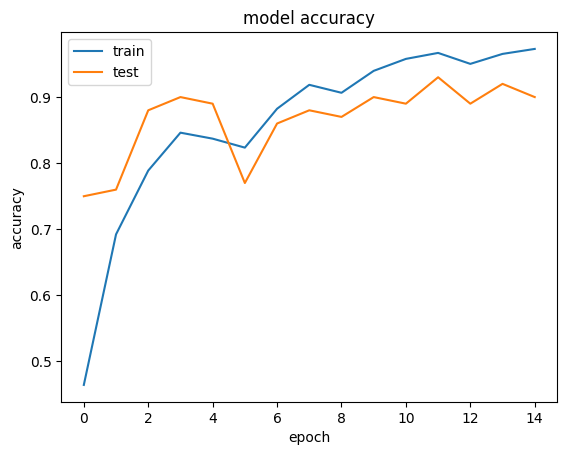

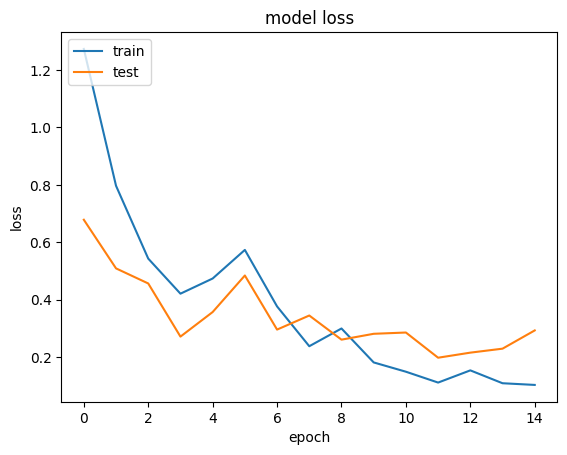

In [22]:
plot_loss_accuracy(history)

In [23]:
import datetime, pytz;
print("Current Time in IST:", datetime.datetime.now(pytz.utc).astimezone(pytz.timezone('Asia/Kolkata')).strftime('%Y-%m-%d %H:%M:%S'))

Current Time in IST: 2026-03-01 21:33:48


In [ ]:
# --- gcolab wrapper: list files in outputs/ ---
import os, datetime
_out_dir = 'outputs'
os.makedirs(_out_dir, exist_ok=True)
print(f"Files in {_out_dir}:")
_files = []
for _fn in os.listdir(_out_dir):
    _fp = os.path.join(_out_dir, _fn)
    if os.path.isfile(_fp):
        _st = os.stat(_fp)
        _files.append((datetime.datetime.fromtimestamp(_st.st_mtime).strftime('%Y-%m-%d %H:%M:%S'), _st.st_size, _fn))
_files.sort()
for _m, _s, _n in _files:
    if _s < 1024:
        _h = f"{_s} B"
    elif _s < 1024*1024:
        _h = f"{_s/1024:.2f} KB"
    else:
        _h = f"{_s/(1024*1024):.2f} MB"
    print(f"{_m}  {_h:>10}  {_n}")


In [ ]:
# --- gcolab wrapper: zip outputs/ -> outputs.zip ---
import os, shutil
os.makedirs('outputs', exist_ok=True)
shutil.make_archive('outputs', 'zip', 'outputs')
print('Created outputs.zip')
